Import the libraires.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Read the data.

In [30]:
df = pd.read_csv('Datasets/cgpa-package.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Plot the data.

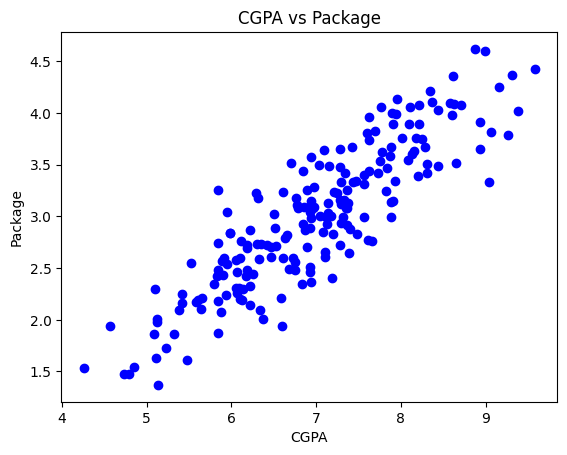

In [31]:
plt.scatter(df['cgpa'], df['package'], color='blue', marker='o')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('CGPA vs Package')
plt.show()

In [32]:
x = df['cgpa']
y = df['package']
x,y

(0      6.89
 1      5.12
 2      7.82
 3      7.42
 4      6.94
        ... 
 195    6.93
 196    5.89
 197    7.21
 198    7.63
 199    6.22
 Name: cgpa, Length: 200, dtype: float64,
 0      3.26
 1      1.98
 2      3.25
 3      3.67
 4      3.57
        ... 
 195    2.46
 196    2.57
 197    3.24
 198    3.96
 199    2.33
 Name: package, Length: 200, dtype: float64)

Train test split.

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160,), (40,), (160,), (40,))

Train the model on linear regression.

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train.values.reshape(-1,1), y_train)
lr.coef_, lr.intercept_

(array([0.55795197]), np.float64(-0.8961119222429144))

Plot the best fit line.

Text(0, 0.5, 'Package(in lpa)')

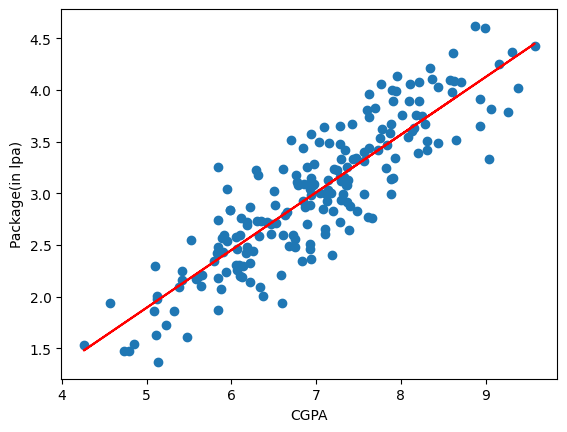

In [35]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train.values.reshape(-1,1)),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

Print the values of regression metrics.

In [36]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred = lr.predict(x_test.values.reshape(-1,1))
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [37]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score",r2_score(y_test,y_pred))
# Adjusted R2 Score
n = len(y_test)
k = 1
adj_r2 = 1 - (1-r2_score(y_test,y_pred)) * (n-1)/(n-k-1)
print("Adjusted R2 Score",adj_r2)

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 Score 0.780730147510384
Adjusted R2 Score 0.7749598882343415


Add a random feature and see the changes in values of regression metrics.

In [38]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.565537,3.26
1,5.12,0.830861,1.98
2,7.82,0.363714,3.25
3,7.42,0.488518,3.67
4,6.94,0.845586,3.57


Text(0, 0.5, 'Package(in lpa)')

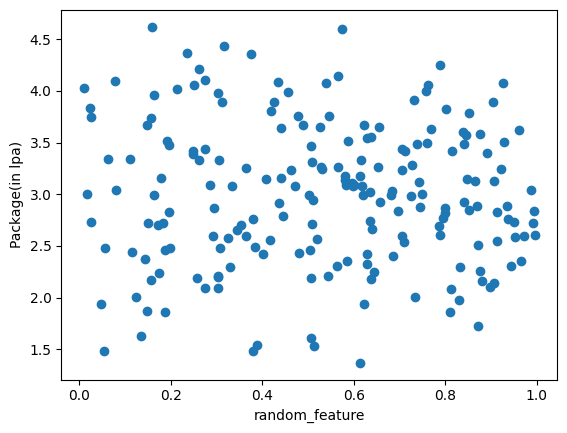

In [39]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [53]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [54]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score",r2_score(y_test,y_pred))
# Adjusted R2 Score
n = len(y_test)
k = 2
adj_r2 = 1 - (1-r2_score(y_test,y_pred)) * (n-1)/(n-k-1)
print("Adjusted R2 Score",adj_r2)

MAE 0.2883513734715894
MSE 0.1210616173409064
RMSE 0.3479391000461236
R2 Score 0.7811472669925075
Adjusted R2 Score 0.7693173895326431


In [55]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]


Text(0, 0.5, 'Package(in lpa)')

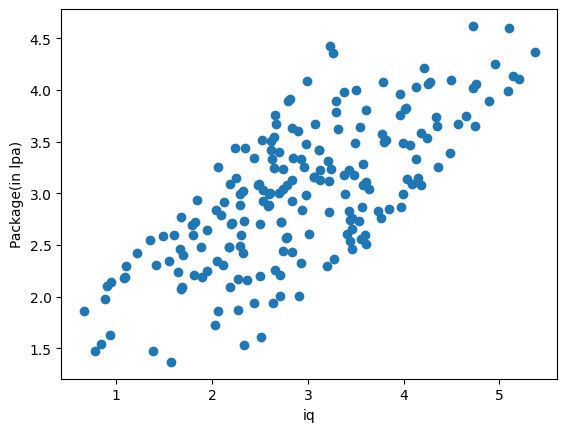

In [56]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [57]:
np.random.randint(-100,100)

-60

In [58]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [59]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))
# Adjusted R2 Score
n = len(y_test)
k = 2
adj_r2 = 1 - (1-r2_score(y_test,y_pred)) * (n-1)/(n-k-1)
print("Adjusted R2 Score",adj_r2) 

MAE 0.2674455016378558
MSE 0.1121819116879527
R2 Score 0.797199818520698
Adjusted R2 Score 0.7862376465488439
